In [1]:
import numpy as np
import cv2 as cv
import matplotlib.pyplot as plt
import os

Antes de comenzar a leer la hora en nuestro reloj, realizaremos un template que nos permitirá separar las manecillas del fondo. Consiste en calcular la media de las imágenes que están en el dataset, obteniendo así una representación del fondo sin las manecillas.

In [2]:

if __name__ == '__main__':
    path = "../data-resampled/"
    hour_clock = []
    for root, dir, files in os.walk(path):   
        for file in files:
            hour_real = file[6:8]
            minute_real = file[8:10]
            hour_clock.append(cv.cvtColor(cv.imread(os.path.join(root,file)), cv.COLOR_BGR2GRAY))

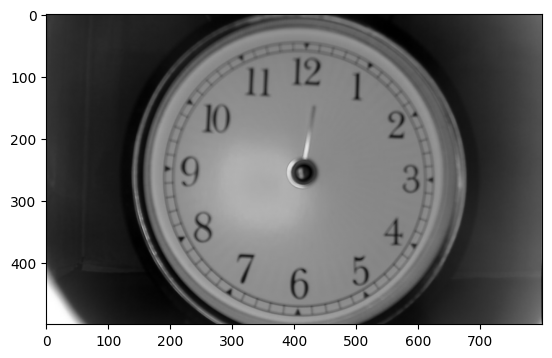

In [3]:
## Apilamos las imágenes 
stacked = np.stack(hour_clock, axis=0)

## Calculamos la media de estas
overlay = np.mean(stacked, axis=0)

plt.imshow(overlay, cmap="gray")

Después de haber realizado nuestro template lo que hacemos es comenzar el preprocesamiento de la imagen que vamos a leer.

In [4]:
# Leemos la imagen.

im = cv.cvtColor(cv.imread("../data-resampled/clock_0840.png"), cv.COLOR_BGR2GRAY)

# Para suavizar aplicamos blur tanto en el overlay como en la imagen a leer.

kernel_size = (5,5) # Definimos un kernel 5x5.

im = cv.GaussianBlur(im, kernel_size,2)

overlay = cv.GaussianBlur(overlay, kernel_size, 2)



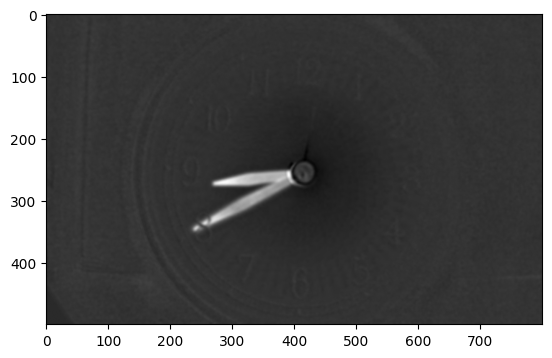

In [5]:
# Al restar las imagenes obtendremos las manecillas sin el fondo del reloj.
clock_hands = overlay - im

plt.imshow(clock_hands, cmap="gray")

# Detectar circulo

In [6]:
circles = cv.HoughCircles(im.astype(np.uint8), cv.HOUGH_GRADIENT, 1, 20, param1=10, param2=50, minRadius=220, maxRadius=225)

detected_circles = im.copy()
for c in circles[0]:
    (x,y,r) = c
    x = int(x)
    y = int(y)
    r = int(r)
    cv.circle(detected_circles, (x, y), r, (255, 255, 255), 8)

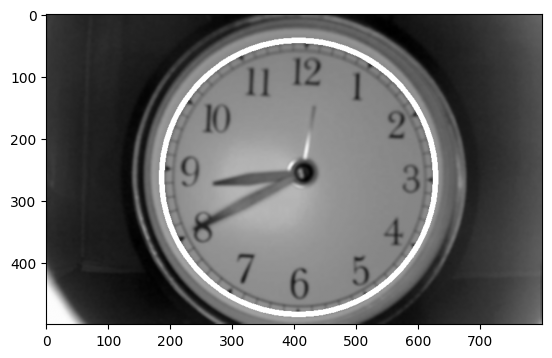

In [7]:
plt.imshow(detected_circles, cmap="gray")
plt.show()

### Teniendo las manecillas separadas del fondo 

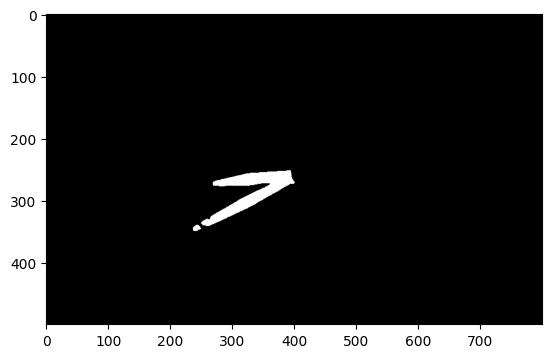

In [8]:
def umbralization(img,t, option1, option2):
    M,N = img.shape

    result = np.zeros((M,N))

    for i in range(M):
        for j in range(N):
            result[i,j] = option1 if img[i,j]  <= t  else option2
    return result

umbralized = 255 - umbralization(clock_hands,40, 255, 0) 
plt.imshow(umbralized, cmap="gray")
plt.show()

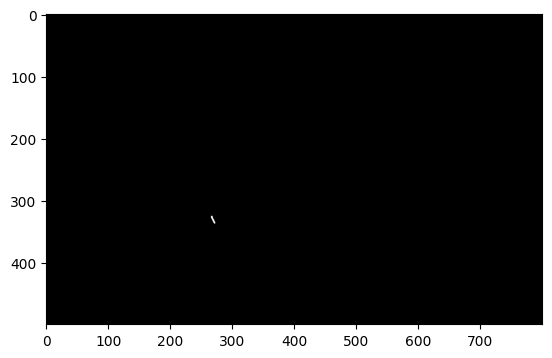

In [9]:
## Obtenemos las coordenadas del centro y el radio.
x_centro = int(circles[0][0][0])
y_centro = int(circles [0][0][1])
radio = int(circles[0][0][2])

center = (x_centro, y_centro)

circle_1_minutes = np.zeros((im.shape))

# Dibujamos un circulo que cubra la manecilla más corta
cv.circle(circle_1_minutes, center, int(radio*0.7),(255,0,0), 2)

# Filtro solo las manecillas de los minutos
minutes = np.multiply(circle_1_minutes, umbralized)

plt.imshow(minutes, cmap="gray")



### Hallamos los minutos

In [10]:
# Hallamos aquellos pixeles cuyo valor sean sea mayor a 0.
y_minutes, x_minutes = np.where(minutes > 0)

distance = np.sqrt((x_minutes-x_centro)**2 + (y_minutes-y_centro)**2)

# Obtengo el indice que contiene la distancia más grande.
manecilla_grande_idx = np.argmax(distance)

### Usando las coordenadas de la punta de la manecilla y el centro del circulo hallado, calculamos el ángulo


Sabiendo que cada minuto tiene una diferencia de 6° porque:

hora = 360°/60 = 6°

Realizamos la conversión después de calcular el ángulo en el que se encuentra

In [11]:

x_punta_g, y_punta_g = x_minutes[manecilla_grande_idx], y_minutes[manecilla_grande_idx]

theta_minutes = (np.degrees(np.arctan2((x_punta_g-x_centro), -(y_punta_g-y_centro))) + 360)

theta_clock = (theta_minutes) % 360

minute_output = np.floor((theta_clock/6) % 60)

minute_output


np.float64(40.0)

### Graficamos la punta hallada de la manecilla de los minutos


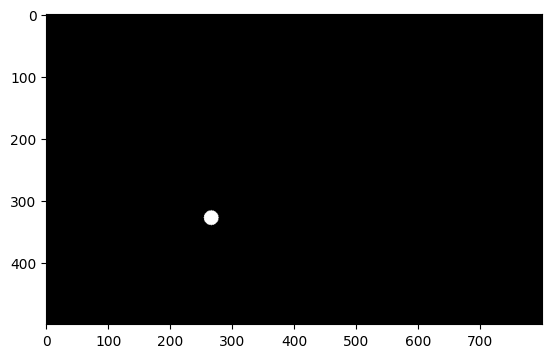

In [12]:
manecilla_minutos = np.zeros(im.shape, dtype=np.uint8)

cv.circle(manecilla_minutos, (int(x_punta_g), int(y_punta_g)), 12, (255,255,255), -1)

plt.imshow(manecilla_minutos,cmap="gray")

### Construimos otro template donde se extraigan tanto las manecillas de los minutos como las horas

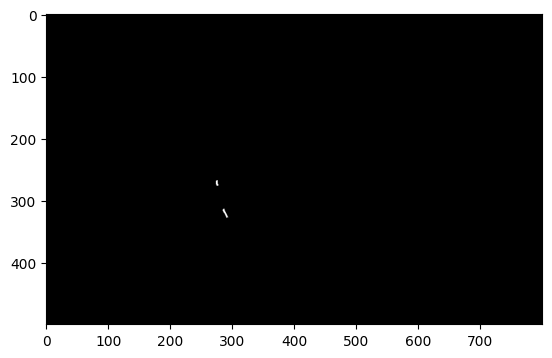

In [13]:
circle_2_hours = np.zeros((im.shape))
cv.circle(circle_2_hours, center, int(radio*0.6),(255,255,255), 2)
hours = circle_2_hours*umbralized
plt.imshow(hours, cmap="gray")

### Usando las coordenadas de las manecillas de los minutos borramos este de la imagen de las horas.

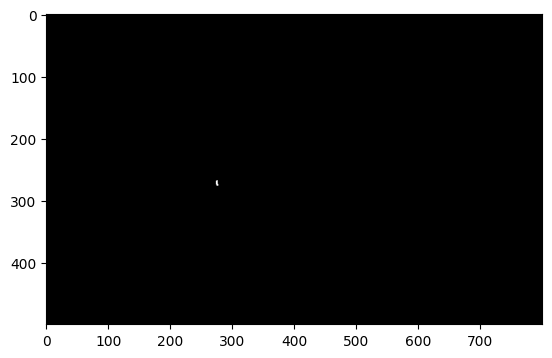

In [14]:
hours_filtered = hours.copy() 
cv.circle(hours_filtered, (int(x_punta_g), int(y_punta_g)), 50, (0,0,0), -1)
plt.imshow(hours_filtered, cmap="gray")

# Hallamos las horas.

In [15]:
y,x = np.where(hours_filtered > 0)

distance = np.sqrt((x - x_centro)**2 + (y - y_centro)**2)

manecilla_pequeña_idx = np.argmax(distance)

Sabiendo que cada hora tiene una diferencia de 30° porque:

hora = 360°/12 = 30°

Realizamos la conversión después de calcular el ángulo en el que se encuentra

In [16]:
x_punta, y_punta = x[manecilla_pequeña_idx], y[manecilla_pequeña_idx]
theta = (np.degrees(np.arctan2((x_punta - x_centro), -(y_punta - y_centro))) + 360) % 360
hour = np.floor(theta/30)%12
hour

np.float64(8.0)

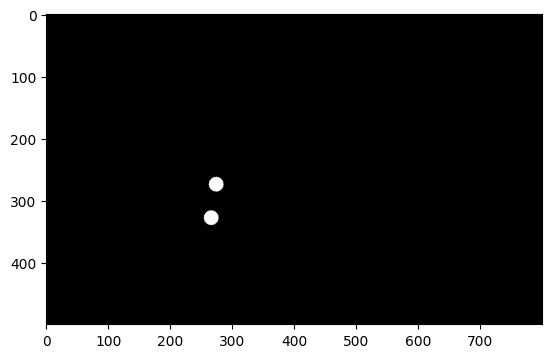

In [17]:
manecilla_horas = np.zeros(im.shape)
cv.circle(manecilla_horas, (int(x_punta), int(y_punta)), 12, (255,255,255), -1)
cv.circle(manecilla_horas, (int(x_punta_g), int(y_punta_g)), 12, (255,255,255), -1)
plt.imshow(manecilla_horas, cmap="gray")

In [18]:
print(f"La hora es {hour} {minute_output}")

La hora es 8.0 40.0
